# Welcome to Colab!

EXPERIMENT 1

Earliest start times: {'A': 0, 'B': 4.0, 'C': 4.0, 'D': 6.0, 'E': 7.0, 'F': 12.0}
Earliest finish times: {'A': 4.0, 'B': 6.0, 'C': 7.0, 'D': 8.333333333333334, 'E': 12.0, 'F': 15.833333333333334}
Latest start times: {'A': 0.0, 'B': 4.0, 'C': 4.0, 'D': 6.0, 'E': 7.0, 'F': 12.0}
Latest finish times: {'A': 4.0, 'B': 6.0, 'C': 7.0, 'D': 8.333333333333334, 'E': 12.0, 'F': 15.833333333333334}
Critical path: ['A', 'B', 'C', 'D', 'E', 'F']
Project duration (expected): 15.833333333333334
Project standard deviation: 1.5


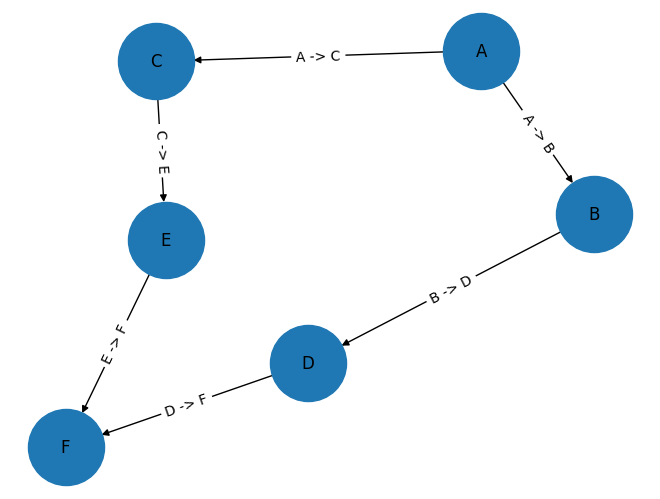

In [30]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': []},
    'B': {'optimistic': 1, 'most_likely': 2, 'pessimistic': 3, 'dependencies': ['A']},
    'C': {'optimistic': 1, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['A']},
    'D': {'optimistic': 2, 'most_likely': 2, 'pessimistic': 4, 'dependencies': ['B']},
    'E': {'optimistic': 3, 'most_likely': 5, 'pessimistic': 7, 'dependencies': ['C']},
    'F': {'optimistic': 1, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['D', 'E']}
}

for task, data in tasks.items():
    data['expected_duration'] = (data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['expected_duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(
            earliest_start[successor],
            earliest_finish[task]
        )

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(
            latest_finish[predecessor],
            latest_start[task]
        )
        latest_start[predecessor] = latest_finish[predecessor] - \
            G.nodes[predecessor]['duration']

critical_path = [
    task for task in topological_order
    if earliest_start[task] == latest_start[task]
]

project_duration = earliest_finish[topological_order[-1]]
project_variance = sum(G.nodes[task]['variance'] for task in critical_path)
project_std_dev = np.sqrt(project_variance)

print("Earliest start times:", earliest_start)
print("Earliest finish times:", earliest_finish)
print("Latest start times:", latest_start)
print("Latest finish times:", latest_finish)
print("Critical path:", critical_path)
print("Project duration (expected):", project_duration)
print("Project standard deviation:", project_std_dev)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={(u, v): f"{u} -> {v}" for u, v in G.edges}
)

plt.show()

EXPERIMENT 2

Critical path: ['B', 'D', 'E', 'F']
Project duration: 16.0
Standard deviation: 1.2583057392117916


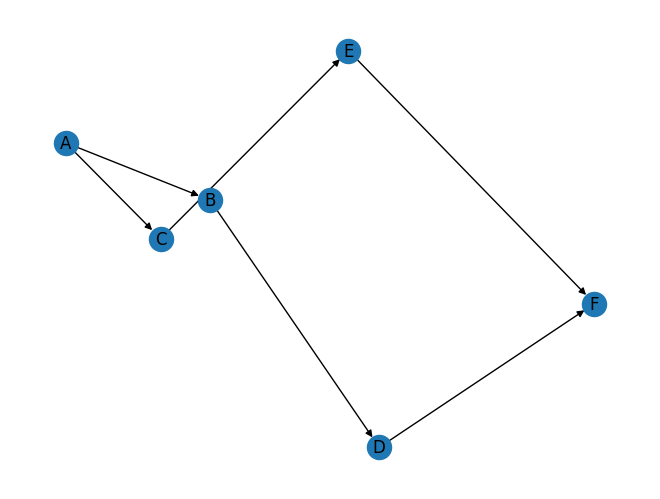

In [31]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'optimistic': 1, 'most_likely': 3, 'pessimistic': 5, 'dependencies': []},
    'B': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['A']},
    'C': {'optimistic': 1, 'most_likely': 2, 'pessimistic': 4, 'dependencies': ['A']},
    'D': {'optimistic': 3, 'most_likely': 5, 'pessimistic': 7, 'dependencies': ['B']},
    'E': {'optimistic': 2, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['C']},
    'F': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['D', 'E']}
}

for task, data in tasks.items():
    data['expected_duration'] = (data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['expected_duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(earliest_start[successor], earliest_finish[task])

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(latest_finish[predecessor], latest_start[task])
        latest_start[predecessor] = latest_finish[predecessor] - G.nodes[predecessor]['duration']

critical_path = [task for task in topological_order if earliest_start[task] == latest_start[task]]

project_duration = earliest_finish[topological_order[-1]]
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std_dev = np.sqrt(project_variance)

print("Critical path:", critical_path)
print("Project duration:", project_duration)
print("Standard deviation:", project_std_dev)

nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 3

Critical path: ['A', 'B', 'C', 'D', 'E', 'F']
Project duration: 18.833333333333332
Standard deviation: 1.922093765778466


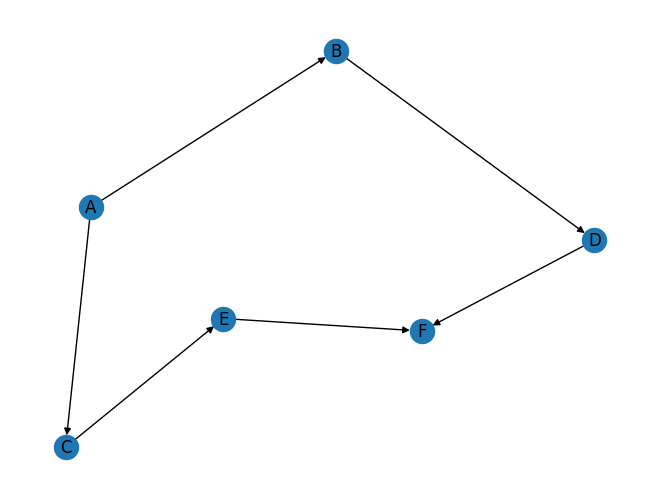

In [32]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'optimistic': 2, 'most_likely': 5, 'pessimistic': 8, 'dependencies': []},
    'B': {'optimistic': 1, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['A']},
    'C': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['A']},
    'D': {'optimistic': 3, 'most_likely': 6, 'pessimistic': 9, 'dependencies': ['B']},
    'E': {'optimistic': 1, 'most_likely': 2, 'pessimistic': 3, 'dependencies': ['C']},
    'F': {'optimistic': 2, 'most_likely': 5, 'pessimistic': 7, 'dependencies': ['D', 'E']}
}

for task, data in tasks.items():
    data['expected_duration'] = (data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['expected_duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(earliest_start[successor], earliest_finish[task])

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(latest_finish[predecessor], latest_start[task])
        latest_start[predecessor] = latest_finish[predecessor] - G.nodes[predecessor]['duration']

critical_path = [task for task in topological_order if earliest_start[task] == latest_start[task]]

project_duration = earliest_finish[topological_order[-1]]
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std_dev = np.sqrt(project_variance)

print("Critical path:", critical_path)
print("Project duration:", project_duration)
print("Standard deviation:", project_std_dev)

nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 4

Critical path: ['A', 'B', 'C', 'D', 'E', 'F']
Project duration: 17.833333333333332
Standard deviation: 1.7159383568311668


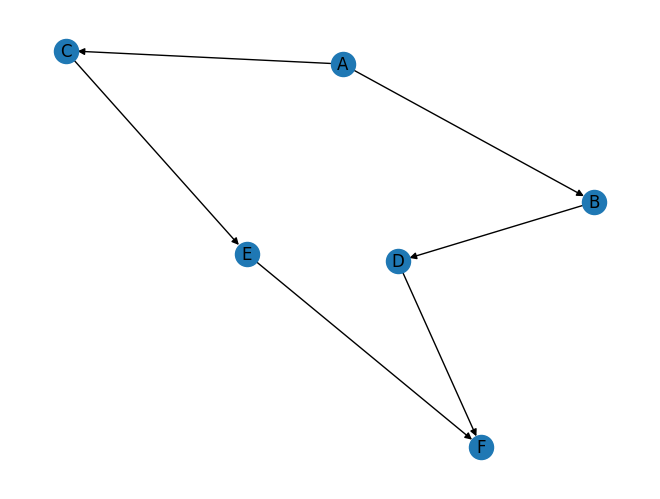

In [33]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'optimistic': 3, 'most_likely': 6, 'pessimistic': 9, 'dependencies': []},
    'B': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['A']},
    'C': {'optimistic': 1, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['A']},
    'D': {'optimistic': 2, 'most_likely': 5, 'pessimistic': 7, 'dependencies': ['B']},
    'E': {'optimistic': 3, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['C']},
    'F': {'optimistic': 2, 'most_likely': 3, 'pessimistic': 4, 'dependencies': ['D', 'E']}
}

for task, data in tasks.items():
    data['expected_duration'] = (data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['expected_duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(earliest_start[successor], earliest_finish[task])

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(latest_finish[predecessor], latest_start[task])
        latest_start[predecessor] = latest_finish[predecessor] - G.nodes[predecessor]['duration']

critical_path = [task for task in topological_order if earliest_start[task] == latest_start[task]]

project_duration = earliest_finish[topological_order[-1]]
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std_dev = np.sqrt(project_variance)

print("Critical path:", critical_path)
print("Project duration:", project_duration)
print("Standard deviation:", project_std_dev)

nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()

EXPERIMENT 5

Critical path: ['A', 'D', 'E', 'F']
Project duration: 18.833333333333332
Standard deviation: 1.6583123951777001


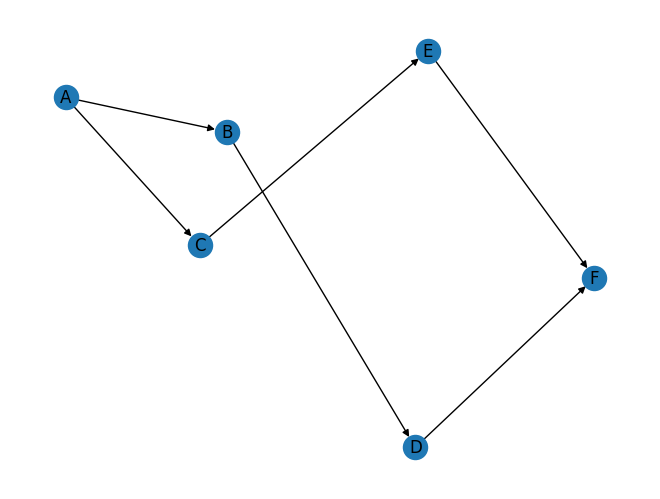

In [34]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

tasks = {
    'A': {'optimistic': 2, 'most_likely': 3, 'pessimistic': 7, 'dependencies': []},
    'B': {'optimistic': 3, 'most_likely': 5, 'pessimistic': 8, 'dependencies': ['A']},
    'C': {'optimistic': 1, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['A']},
    'D': {'optimistic': 2, 'most_likely': 6, 'pessimistic': 9, 'dependencies': ['B']},
    'E': {'optimistic': 2, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['C']},
    'F': {'optimistic': 3, 'most_likely': 4, 'pessimistic': 7, 'dependencies': ['D', 'E']}
}

for task, data in tasks.items():
    data['expected_duration'] = (data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

G = nx.DiGraph()

for task, data in tasks.items():
    G.add_node(task, duration=data['expected_duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

topological_order = list(nx.topological_sort(G))

earliest_start = {task: 0 for task in topological_order}
earliest_finish = {task: 0 for task in topological_order}

for task in topological_order:
    earliest_finish[task] = earliest_start[task] + G.nodes[task]['duration']
    for successor in G.successors(task):
        earliest_start[successor] = max(earliest_start[successor], earliest_finish[task])

latest_finish = {task: earliest_finish[task] for task in topological_order}
latest_start = {task: earliest_start[task] for task in topological_order}

for task in reversed(topological_order):
    for predecessor in G.predecessors(task):
        latest_finish[predecessor] = min(latest_finish[predecessor], latest_start[task])
        latest_start[predecessor] = latest_finish[predecessor] - G.nodes[predecessor]['duration']

critical_path = [task for task in topological_order if earliest_start[task] == latest_start[task]]

project_duration = earliest_finish[topological_order[-1]]
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std_dev = np.sqrt(project_variance)

print("Critical path:", critical_path)
print("Project duration:", project_duration)
print("Standard deviation:", project_std_dev)

nx.draw(G, nx.spring_layout(G), with_labels=True)
plt.show()